## 1. Постановка задачи и обоснование применения ML

### 1.1. Бизнес‑проблема и предметная область
Отток клиентов (churn) – одна из ключевых проблем телекоммуникационных компаний. Стоимость привлечения нового абонента (CAC) в телекоме в среднем в 5–7 раз превышает затраты на удержание существующего. Даже небольшое снижение уровня оттока на 2–3% может привести к росту годовой прибыли на десятки миллионов рублей для крупного оператора.

**Предметная область:**  
Работаем с датасетом `Telco Customer Churn`, содержащим информацию о 7 043 клиентах: демографию, характеристики тарифов, набор подключённых услуг, длительность обслуживания и факт ухода. Задача – построить предиктивную модель, которая на основе исторических данных предскажет вероятность того, что клиент покинет компанию в ближайшем расчётном периоде.

### 1.2. Тип задачи и выбор метрик
**Тип задачи:** бинарная классификация (уйдёт / не уйдёт).  
**Целевая метрика:** **ROC‑AUC**.  
В условиях дисбаланса классов (~27% ушедших) accuracy не является надёжной метрикой, так как модель, предсказывающая «не уйдёт» для всех, получит accuracy ~73%. ROC‑AUC показывает способность модели разделять классы независимо от порога и является стандартом в задачах прогнозирования оттока.  
**Бизнес‑метрики (контролируемые дополнительно):**
- **Recall (полнота)** – чтобы не пропустить как можно больше клиентов, склонных к уходу.
- **Precision (точность)** – чтобы не тратить бюджет на удержание лояльных клиентов, ошибочно отнесённых к группе риска.

### 1.3. Допущения и ожидаемый бизнес‑эффект
**Допущения:**
- Исторические данные отражают реальные паттерны поведения клиентов, которые сохранятся в ближайшем будущем.
- Признаки, собранные за всё время обслуживания (tenure, TotalCharges), корректно фиксируют «возраст» клиента и его накопленные расходы.
- Отсутствие сильного дрейфа данных в краткосрочной перспективе.

**Ожидаемый эффект от внедрения:**  
Модель позволит отделу маркетинга и удержания формировать пул клиентов с высокой вероятностью оттока для превентивных акций (персональные скидки, предложение годового контракта, бесплатный тестовый период дополнительных услуг). Прогнозируемое снижение оттока на 5–10% даст значительный экономический эффект за счёт сохранения выручки и снижения затрат на привлечение новых абонентов.

## 2. Установка и импорт библиотек

In [37]:
!pip install shap catboost -q
!pip install fastapi uvicorn pyngrok nest-asyncio -q

# Стандартные библиотеки для работы с данными
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Библиотеки для машинного обучения
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, classification_report, confusion_matrix,
                             roc_curve, precision_recall_curve)
import xgboost as xgb
from catboost import CatBoostClassifier

# Для интерпретации модели
import shap

# Для сохранения модели
import joblib
import json

# Настройка визуализации
import nest_asyncio
from pyngrok import ngrok
import uvicorn
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
import warnings
warnings.filterwarnings('ignore')

print("Все библиотеки успешно импортированы.")

Все библиотеки успешно импортированы.


## 3. Загрузка и первичный осмотр данных

In [38]:
# Загрузка датасета
url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
df = pd.read_csv(url)

print("Датасет успешно загружен.")

# Первичный осмотр
print(f"Размер датасета (строк, столбцов): {df.shape}")
print("\nПервые 5 строк датасета:")
df.head()

Датасет успешно загружен.
Размер датасета (строк, столбцов): (7043, 21)

Первые 5 строк датасета:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 3.1 Информация о датасете

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### 3.2 Проверка на пропуски

In [40]:
print("Пропуски в данных:")
df.isnull().sum()

Пропуски в данных:


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


### 3.3 Преобразование столбца TotalCharges в числовой формат

In [41]:
# В исходном датасете он может быть загружен как object из-за пробелов
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Проверяем, сколько NaN появилось после преобразования
print(f"Количество NaN в TotalCharges: {df['TotalCharges'].isnull().sum()}")

Количество NaN в TotalCharges: 11


## 4. Разведочный анализ данных (EDA)

Распределение целевой переменной 'Churn':
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


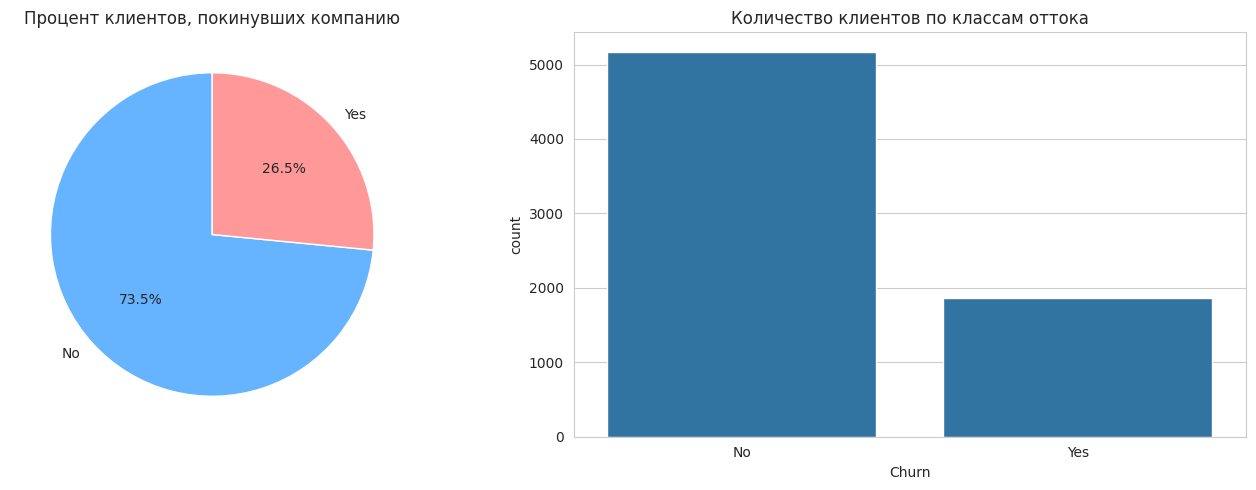

In [42]:
# Анализ целевой переменной 'Churn'
churn_counts = df['Churn'].value_counts(normalize=True) * 100
print(f"Распределение целевой переменной 'Churn':\n{churn_counts}")

# Визуализация дисбаланса классов
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
# Круговая диаграмма
ax[0].pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%', startangle=90, colors=['#66b3ff','#ff9999'])
ax[0].set_title('Процент клиентов, покинувших компанию')
# Столбчатая диаграмма
sns.countplot(x='Churn', data=df, ax=ax[1])
ax[1].set_title('Количество клиентов по классам оттока')
plt.tight_layout()
plt.show()

# Вывод: Классы несбалансированы, что нужно будет учесть при валидации и выборе метрик.

### 4.1. Анализ целевой переменной

In [43]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
df[numerical_cols].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7032.000000
mean,32.371149,64.761692,2283.300441
std,24.559481,30.090047,2266.771362
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3794.737500
max,72.000000,118.750000,8684.800000


### 4.2. Анализ числовых признаков

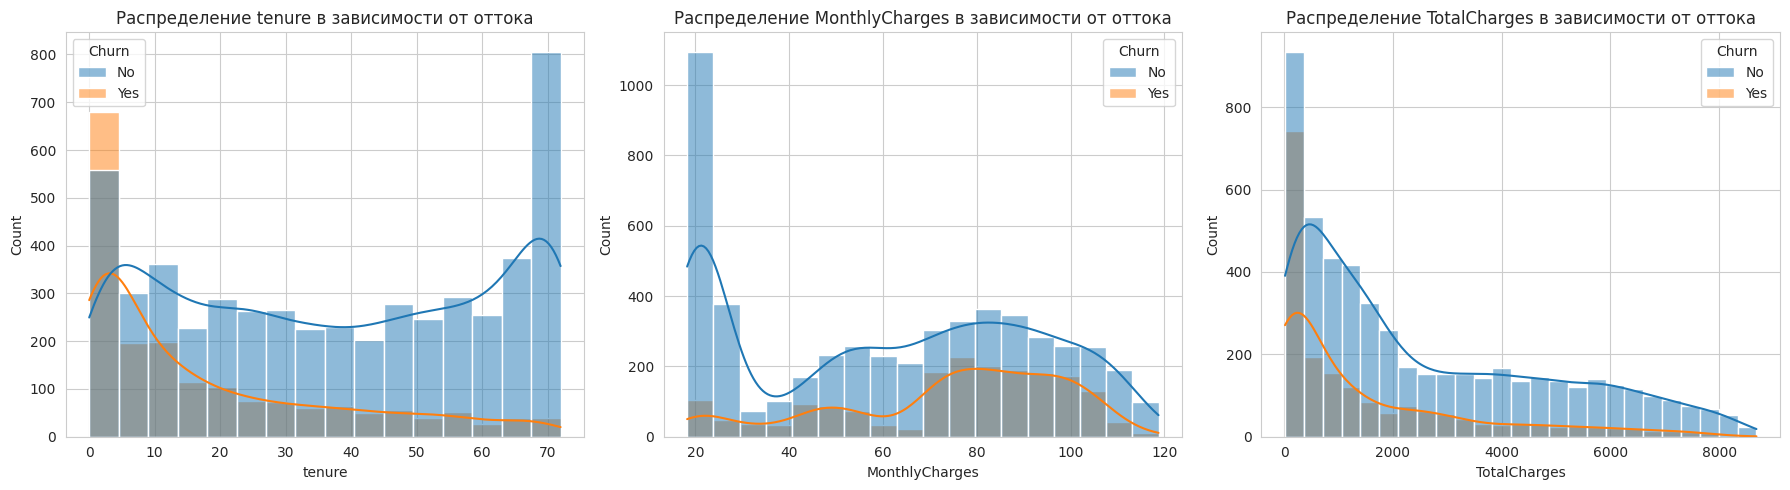

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(numerical_cols):
    sns.histplot(data=df, x=col, hue='Churn', kde=True, ax=axes[i])
    axes[i].set_title(f'Распределение {col} в зависимости от оттока')
plt.tight_layout()
plt.show()

Вывод: Наблюдается четкая обратная зависимость между `tenure` и оттоком: клиенты с длительностью обслуживания менее 10 месяцев составляют значительную долю ушедших. Высокие ежемесячные расходы (выше 70 у.е.) также являются сильным индикатором оттока, особенно в сочетании с коротким контрактом (помесячная оплата). Признак `TotalCharges` будет менее информативен в отрыве от `tenure`, что учтено в дальнейшем при создании признака `AvgMonthlyCharges`.

### 4.3. Анализ категориальных признаков

Категориальные признаки для анализа: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


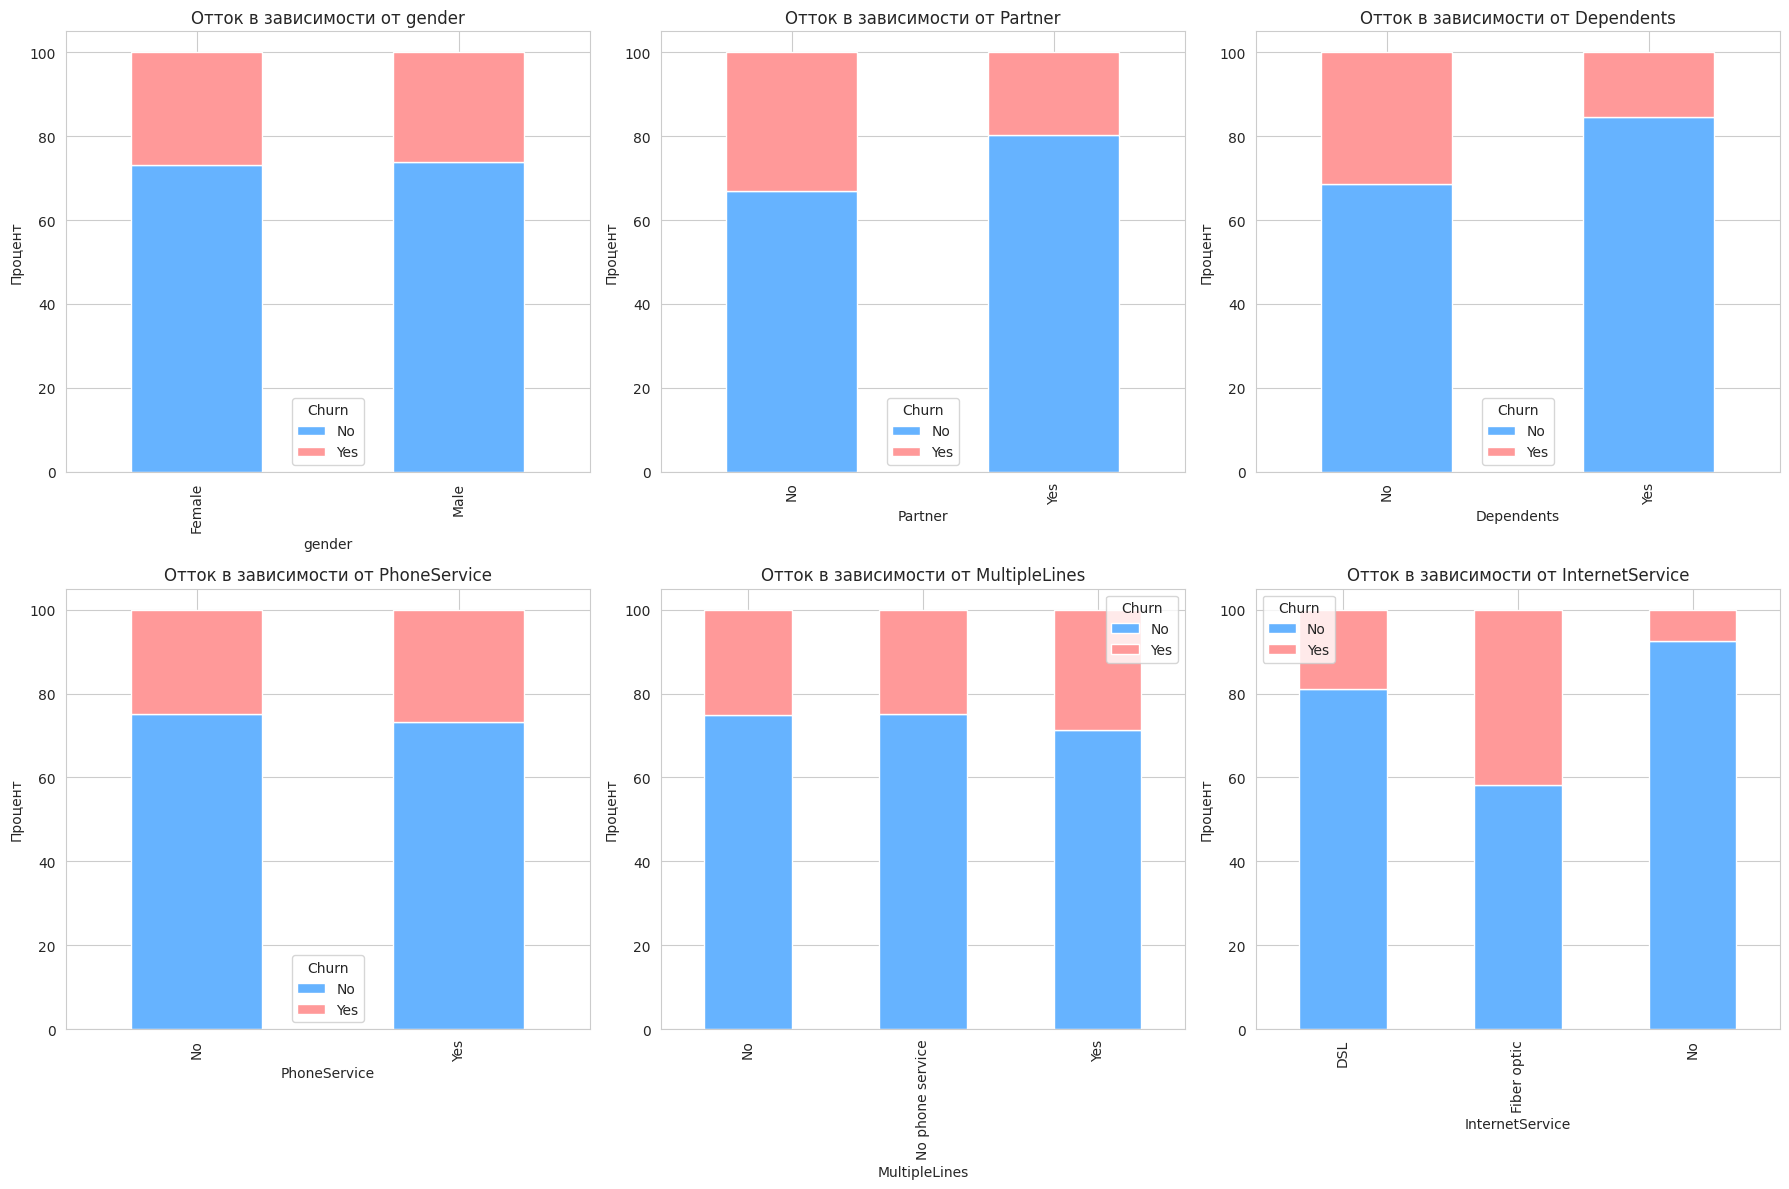

In [45]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols.remove('customerID') # Убираем идентификатор
categorical_cols.remove('Churn') # Убираем целевую переменную

print(f"Категориальные признаки для анализа: {categorical_cols}")

# Визуализация связи некоторых категориальных признаков с оттоком
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()
for i, col in enumerate(categorical_cols[:6]): # Возьмем первые 6 для примера
    cross_tab = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
    cross_tab.plot(kind='bar', stacked=True, ax=axes[i], color=['#66b3ff','#ff9999'])
    axes[i].set_title(f'Отток в зависимости от {col}')
    axes[i].set_ylabel('Процент')
plt.tight_layout()
plt.show()


### 4.4. Ключевые инсайты по итогам EDA

**Ключевые инсайты по итогам EDA:**

1. **Длительность обслуживания (tenure)** – самый мощный одиночный предиктор. Клиенты с tenure менее 10 месяцев уходят в разы чаще, чем «старожилы». Пик оттока приходится на первые 3–6 месяцев после подключения. Это указывает на необходимость усиленной работы с новыми абонентами в первые полгода.

2. **Ежемесячные платежи (MonthlyCharges) и контракт (Contract)** работают в связке. Абоненты с помесячной оплатой (Month‑to‑month) и высоким чеком (>70 у.е.) демонстрируют наибольший риск оттока. Переход на годовой контракт резко снижает вероятность ухода – даже при тех же значениях MonthlyCharges.

3. **Дополнительные услуги (онлайн‑безопасность, техподдержка, бэкап)** имеют выраженный «удерживающий» эффект. Клиенты, у которых подключена хотя бы одна из этих услуг, реже покидают компанию. Вероятно, это связано с более высокой вовлечённостью и воспринимаемой ценностью сервиса.

4. **Способ оплаты (PaymentMethod)** – электронные чеки (Electronic check) заметно коррелируют с оттоком. Возможные причины: неудобство ручного пополнения, комиссии или ассоциация с менее платёжеспособной аудиторией.

5. **Семейное положение и наличие иждивенцев** влияют слабее, но клиенты с партнёром и иждивенцами чуть более лояльны – предположительно из‑за более стабильного социального положения и нежелания менять привычный сервис.

Эти наблюдения легли в основу дальнейшего Feature Engineering (создание признаков `AvgMonthlyCharges`, `NumServices`) и будут использованы при формулировке бизнес‑рекомендаций.

## 5. Предобработка данных и Feature Engineering

In [46]:
# Создаем копию датафрейма для обработки
df_processed = df.copy()

# 1. Обработка TotalCharges: заполним NaN медианой (или можно нулями, если считаем, что это новые клиенты)
df_processed['TotalCharges'].fillna(df_processed['TotalCharges'].median(), inplace=True)

# 2. Кодирование целевой переменной Churn в бинарный формат
df_processed['Churn'] = df_processed['Churn'].map({'Yes': 1, 'No': 0})

# 3. Feature Engineering: создадим новые признаки
# Признак: средние траты в месяц за всё время
df_processed['AvgMonthlyCharges'] = df_processed['TotalCharges'] / (df_processed['tenure'] + 1) # +1 для избежания деления на 0
# Признак: количество дополнительных услуг (суммируем бинарные признаки услуг)
service_cols = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
                'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
# Преобразуем 'No internet service' и 'No phone service' в 'No' для упрощения
for col in service_cols:
    df_processed[col] = df_processed[col].apply(lambda x: 'Yes' if x == 'Yes' else 'No')
# Создаем бинарные признаки и считаем сумму
service_binary = pd.get_dummies(df_processed[service_cols], drop_first=True)
df_processed['NumServices'] = service_binary.sum(axis=1)

# 4. Кодирование категориальных признаков
# Для бинарных категорий с 'Yes'/'No' применяем Label Encoding
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col])

# Для остальных категорий применяем One-Hot Encoding
categorical_cols_to_encode = [col for col in categorical_cols if col not in binary_cols and col not in service_cols]
df_processed = pd.get_dummies(df_processed, columns=categorical_cols_to_encode, drop_first=True)

# 5. Масштабирование числовых признаков
scaler = StandardScaler()
numerical_cols_extended = numerical_cols + ['AvgMonthlyCharges', 'NumServices']
df_processed[numerical_cols_extended] = scaler.fit_transform(df_processed[numerical_cols_extended])

# Удаляем идентификатор клиента и исходные колонки услуг (если они остались после get_dummies)
df_processed.drop(columns=['customerID'], inplace=True)
cols_to_drop = [col for col in df_processed.columns if col in service_cols]
df_processed.drop(columns=cols_to_drop, inplace=True, errors='ignore')

print("Предобработка данных завершена.")
print(f"Итоговый размер данных: {df_processed.shape}")
df_processed.head()

Предобработка данных завершена.
Итоговый размер данных: (7043, 16)


,gender,SeniorCitizen,Partner,Dependents,tenure,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,AvgMonthlyCharges,NumServices,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,-1.277445,1,-1.160323,-0.994242,0,-0.757979,-1.145997,False,False,False,True,False
1,1,0,0,0,0.066327,0,-0.259629,-0.173244,0,-0.117801,-0.176011,True,False,False,False,True
2,1,0,0,0,-1.236724,1,-0.362660,-0.959674,1,-0.411755,-0.176011,False,False,False,False,True
3,1,0,0,0,0.514251,0,-0.746535,-0.194766,0,-0.346750,-0.176011,True,False,False,False,False
4,0,0,0,0,-1.236724,1,0.197365,-0.940470,1,-0.174110,-1.145997,False,False,False,True,False


## 6. Разделение данных и Baseline‑модель

In [47]:
# Разделение на признаки (X) и целевую переменную (y)
X = df_processed.drop('Churn', axis=1)
y = df_processed['Churn']

# Разделение на train (70%) и temp (30%) с сохранением пропорций классов
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
# Разделение temp на validation (15%) и test (15%)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Размер обучающей выборки: {X_train.shape[0]} (отток: {y_train.sum()})")
print(f"Размер валидационной выборки: {X_val.shape[0]} (отток: {y_val.sum()})")
print(f"Размер тестовой выборки: {X_test.shape[0]} (отток: {y_test.sum()})")

Размер обучающей выборки: 4930 (отток: 1308)
Размер валидационной выборки: 1056 (отток: 280)
Размер тестовой выборки: 1057 (отток: 281)


### 6.1. Инициализация и обучение baseline (логистическая регрессия)

In [48]:
baseline_model = LogisticRegression(random_state=42, max_iter=1000)
baseline_model.fit(X_train, y_train)

# Предсказание на валидационной выборке
y_val_pred = baseline_model.predict(X_val)
y_val_pred_proba = baseline_model.predict_proba(X_val)[:, 1]

# Оценка качества
print("=== Качество Baseline-модели (Logistic Regression) ===")
print(f"Accuracy: {accuracy_score(y_val, y_val_pred):.4f}")
print(f"Precision: {precision_score(y_val, y_val_pred):.4f}")
print(f"Recall: {recall_score(y_val, y_val_pred):.4f}")
print(f"F1-score: {f1_score(y_val, y_val_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_val, y_val_pred_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred))

=== Качество Baseline-модели (Logistic Regression) ===
Accuracy: 0.7973
Precision: 0.6387
Recall: 0.5429
F1-score: 0.5869
ROC-AUC: 0.8384

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.87       776
           1       0.64      0.54      0.59       280

    accuracy                           0.80      1056
   macro avg       0.74      0.72      0.73      1056
weighted avg       0.79      0.80      0.79      1056



## 7. Продвинутые модели и подбор гиперпараметров

In [49]:
# Функция для оценки модели на валидационной выборке
def evaluate_model(model, X_val, y_val, model_name):
    y_pred = model.predict(X_val)
    y_pred_proba = model.predict_proba(X_val)[:, 1]
    print(f"=== {model_name} ===")
    print(f"Accuracy: {accuracy_score(y_val, y_pred):.4f}")
    print(f"Precision: {precision_score(y_val, y_pred):.4f}")
    print(f"Recall: {recall_score(y_val, y_pred):.4f}")
    print(f"F1-score: {f1_score(y_val, y_pred):.4f}")
    print(f"ROC-AUC: {roc_auc_score(y_val, y_pred_proba):.4f}")
    print("-" * 30)
    return {'Model': model_name, 'Accuracy': accuracy_score(y_val, y_pred),
            'Precision': precision_score(y_val, y_pred), 'Recall': recall_score(y_val, y_pred),
            'F1': f1_score(y_val, y_pred), 'ROC-AUC': roc_auc_score(y_val, y_pred_proba)}

### 7.1. Random Forest

In [50]:
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
rf = RandomForestClassifier(random_state=42)
rf_cv = RandomizedSearchCV(rf, rf_params, cv=StratifiedKFold(3), scoring='roc_auc', n_iter=10, random_state=42, n_jobs=-1)
rf_cv.fit(X_train, y_train)
best_rf = rf_cv.best_estimator_
results = []
results.append(evaluate_model(best_rf, X_val, y_val, "Random Forest (tuned)"))

=== Random Forest (tuned) ===
Accuracy: 0.7907
Precision: 0.6359
Recall: 0.4929
F1-score: 0.5553
ROC-AUC: 0.8434
------------------------------


### 7.2. XGBoost

In [51]:
xgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}
xgb_model = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_cv = RandomizedSearchCV(xgb_model, xgb_params, cv=StratifiedKFold(3), scoring='roc_auc', n_iter=10, random_state=42, n_jobs=-1)
xgb_cv.fit(X_train, y_train)
best_xgb = xgb_cv.best_estimator_
results.append(evaluate_model(best_xgb, X_val, y_val, "XGBoost (tuned)"))

=== XGBoost (tuned) ===
Accuracy: 0.7955
Precision: 0.6758
Recall: 0.4393
F1-score: 0.5325
ROC-AUC: 0.8435
------------------------------


### 7.3. CatBoost

In [52]:
cb_params = {
    'iterations': [100, 200, 300],
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.1, 0.2],
    'l2_leaf_reg': [1, 3, 5]
}
cb_model = CatBoostClassifier(random_state=42, verbose=False)
cb_cv = RandomizedSearchCV(cb_model, cb_params, cv=StratifiedKFold(3), scoring='roc_auc', n_iter=10, random_state=42, n_jobs=-1)
cb_cv.fit(X_train, y_train)
best_cb = cb_cv.best_estimator_
results.append(evaluate_model(best_cb, X_val, y_val, "CatBoost (tuned)"))

=== CatBoost (tuned) ===
Accuracy: 0.7917
Precision: 0.6304
Recall: 0.5179
F1-score: 0.5686
ROC-AUC: 0.8468
------------------------------


### 7.4. Сводная таблица результатов

In [53]:
results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Random Forest (tuned),0.790720,0.635945,0.492857,0.555332,0.843444
1,XGBoost (tuned),0.795455,0.675824,0.439286,0.532468,0.843518
2,CatBoost (tuned),0.791667,0.630435,0.517857,0.568627,0.846845


## 8. Финальная оценка на тестовой выборке

### 8.1. Матрица ошибок

=== Финальная оценка на тестовой выборке ===
Accuracy: 0.7890
Precision: 0.6747
Recall: 0.3986
F1-score: 0.5011
ROC-AUC: 0.8335

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.93      0.87       776
           1       0.67      0.40      0.50       281

    accuracy                           0.79      1057
   macro avg       0.74      0.66      0.68      1057
weighted avg       0.77      0.79      0.77      1057



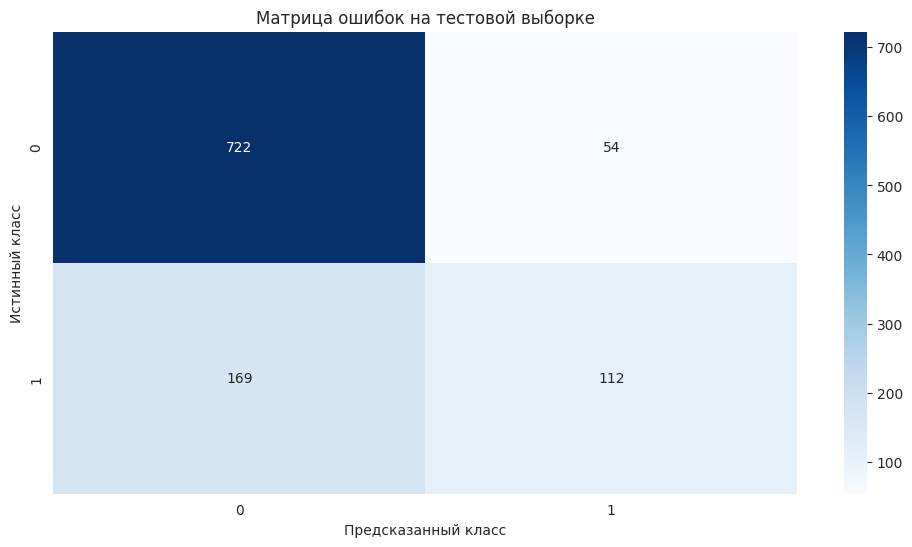

In [54]:
# Допустим, лучшей оказалась модель XGBoost (проверьте по своей таблице результатов)
best_model = best_xgb

# Предсказание на тестовой выборке
y_test_pred = best_model.predict(X_test)
y_test_pred_proba = best_model.predict_proba(X_test)[:, 1]

print("=== Финальная оценка на тестовой выборке ===")
print(f"Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_test_pred):.4f}")
print(f"F1-score: {f1_score(y_test, y_test_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_test_pred_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

# Матрица ошибок
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Матрица ошибок на тестовой выборке')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()



### 8.2. ROC‑кривая

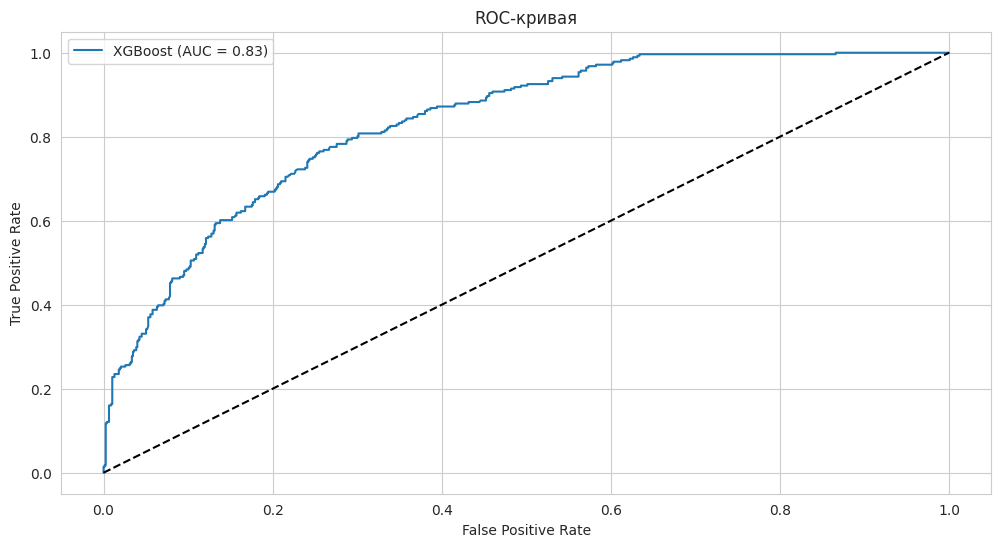

In [55]:
# ROC-кривая
fpr, tpr, _ = roc_curve(y_test, y_test_pred_proba)
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {roc_auc_score(y_test, y_test_pred_proba):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая')
plt.legend()
plt.show()

## 9. Интерпретация модели
Проанализируем важность признаков с помощью встроенной важности и SHAP-значений

### 9.1. Встроенная важность признаков (XGBoost)

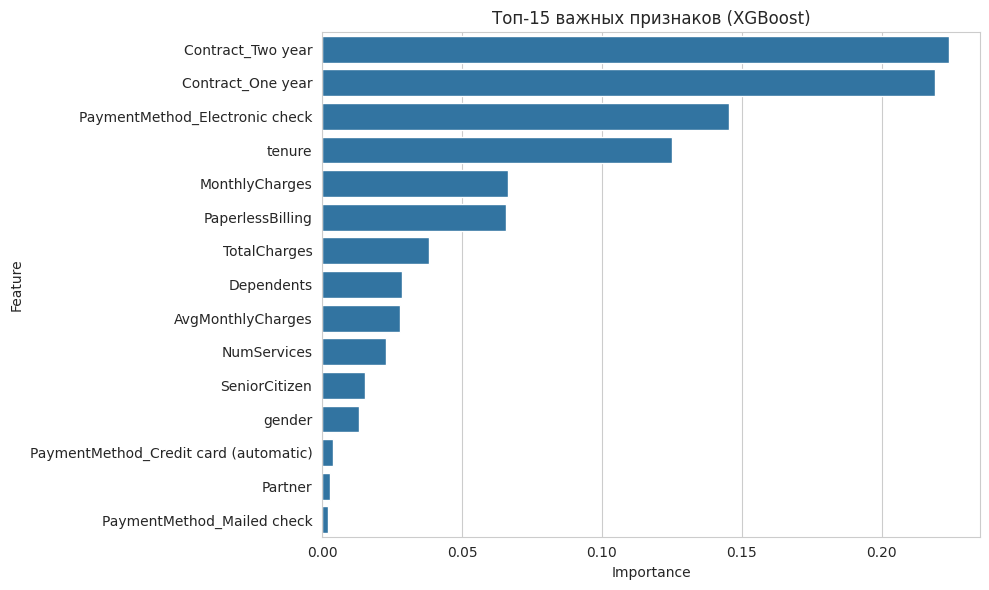

In [56]:
feature_importance = best_model.feature_importances_
feature_names = X_train.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importance})
importance_df = importance_df.sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Топ-15 важных признаков (XGBoost)')
plt.tight_layout()
plt.show()

### 9.2. SHAP‑анализ (глобальная и локальная интерпретация)

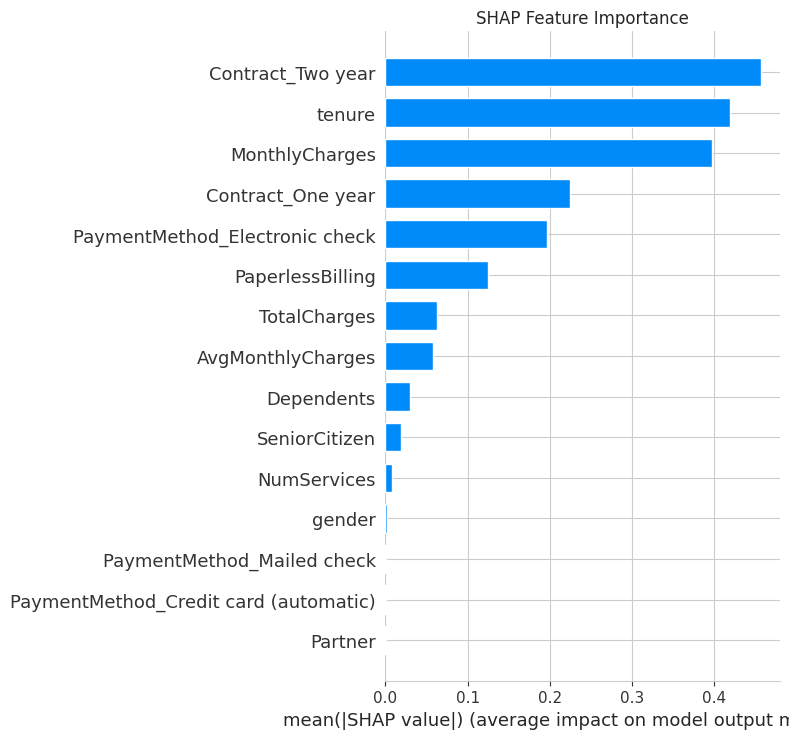

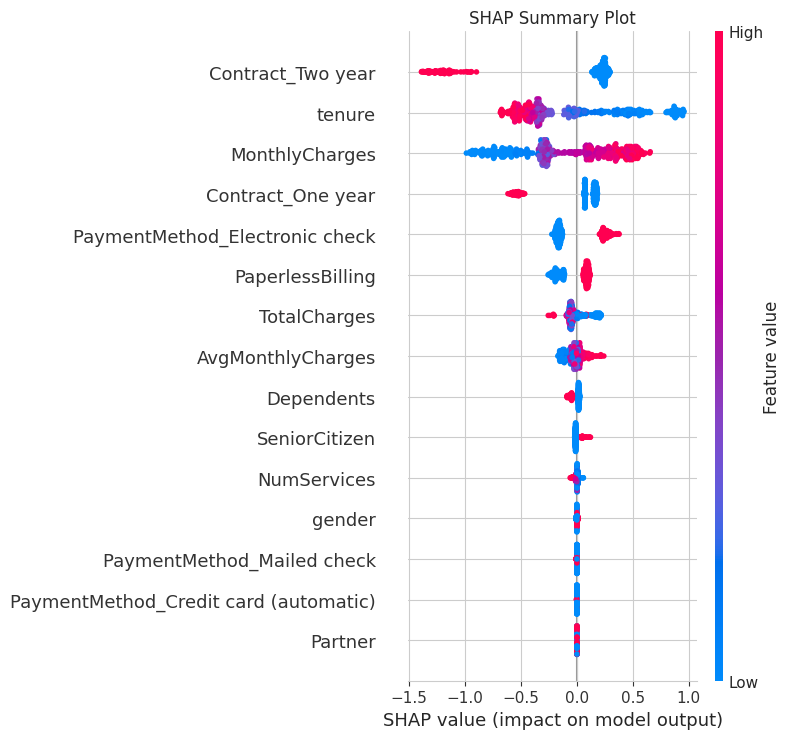

In [57]:
# Создаем объяснитель SHAP (используем подвыборку для ускорения)
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test[:500]) # Берем 500 примеров для скорости

# Сводный график (глобальная важность)
shap.summary_plot(shap_values, X_test[:500], plot_type="bar", show=False)
plt.title('SHAP Feature Importance')
plt.tight_layout()
plt.show()

# Сводный график с детализацией влияния
shap.summary_plot(shap_values, X_test[:500], show=False)
plt.title('SHAP Summary Plot')
plt.tight_layout()
plt.show()

## 10. Прикладные выводы, рекомендации и ограничения модели

### 10.1. Бизнес‑рекомендации по использованию модели

**1. Программа удержания для новых клиентов.**  
Клиенты с tenure < 12 месяцев и помесячной оплатой находятся в зоне максимального риска. Рекомендуется в течение первых 3 месяцев предлагать им скидку при переходе на годовой контракт или пакет «лояльность» с фиксированной ценой на 12 месяцев.

**2. Стимулирование подключения дополнительных услуг.**  
Признак `OnlineSecurity_No` (отсутствие онлайн‑безопасности) оказывает значительное положительное влияние на вероятность оттока согласно SHAP‑анализу. Предложение бесплатного тестового периода (1 месяц) этой услуги с последующей платной подпиской может повысить удержание.

**3. Работа с клиентами, использующими электронные чеки.**  
Абонентам с `PaymentMethod = Electronic check` стоит направить коммуникацию о преимуществах автоплатежа (скидка, кэшбэк, удобство). Дополнительно можно провести опрос среди этой группы для выявления истинных причин неудобства.

**4. Проактивный мониторинг и сегментация.**  
Внедрить ежемесячный скоринг всех активных клиентов. Клиентам с вероятностью оттока >0.7 автоматически направлять персональное предложение от отдела удержания.

### 10.2. Ограничения и риски модели

| Ограничение / риск | Описание |
|-------------------|----------|
| **Дрейф данных** | Модель обучена на статичном историческом срезе. Изменение тарифной политики, появление новых услуг или активные действия конкурентов могут снизить точность прогнозов. Требуется регулярное переобучение (раз в 3–6 месяцев) и мониторинг стабильности входных признаков. |
| **Корреляция ≠ причинность** | Модель показывает статистические связи, но не гарантирует, что изменение одного признака (например, перевод на годовой контракт) приведёт к прогнозируемому снижению оттока для конкретного клиента. Необходим A/B‑тест при внедрении рекомендаций. |
| **Этический аспект** | Недопустимо использовать модель для дискриминации (например, отключение услуг «потенциальному уходящему» без предупреждения). Результаты прогноза должны применяться только для проактивной помощи и улучшения клиентского опыта. |
| **Качество данных** | Признак `TotalCharges` в исходных данных содержал пропуски (11 строк), которые были заполнены медианой. При поступлении реальных данных возможны аналогичные артефакты – необходимо предусмотреть их обработку в пайплайне. |
| **Интерпретируемость для бизнес‑пользователей** | SHAP‑значения дают детальное объяснение, но для ежедневной работы менеджеров по удержанию достаточно выводить топ‑3 причины риска в читаемом виде (например, «короткий стаж + помесячный контракт»). |

Локальная интерпретация для одного клиента (например, первого из тестовой выборки)

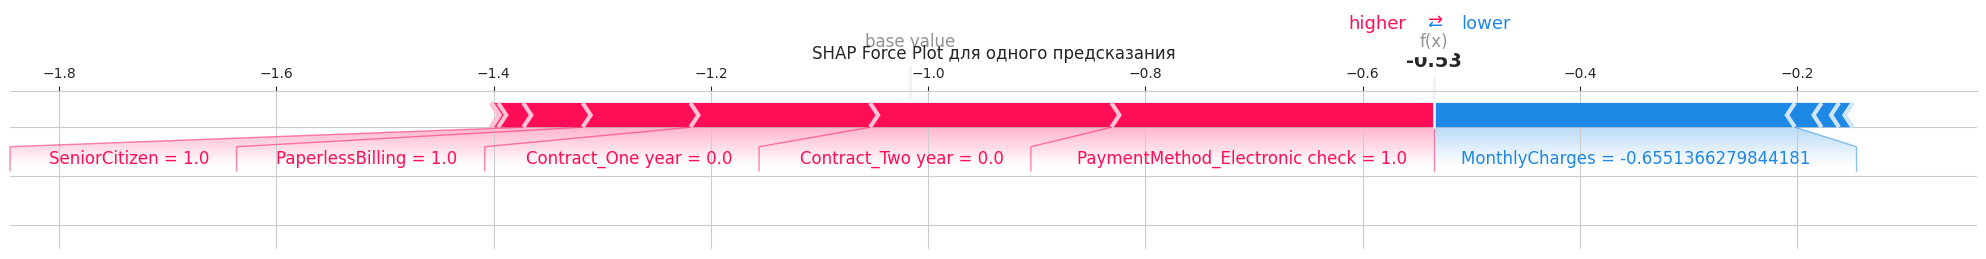

In [58]:
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[0,:], X_test.iloc[0,:], matplotlib=True, show=False)
plt.title('SHAP Force Plot для одного предсказания')
plt.tight_layout()
plt.show()

## 11. Сохранение модели и артефактов

In [59]:
# Сохраняем модель
joblib.dump(best_model, 'best_churn_model.pkl')

# Сохраняем скейлер (мы использовали StandardScaler при предобработке)
joblib.dump(scaler, 'scaler.pkl')

# Сохраняем список признаков, которые ожидает модель
feature_names = X_train.columns.tolist()
with open('feature_names.json', 'w') as f:
    json.dump(feature_names, f)

print("Модель, скейлер и список признаков сохранены.")

Модель, скейлер и список признаков сохранены.
